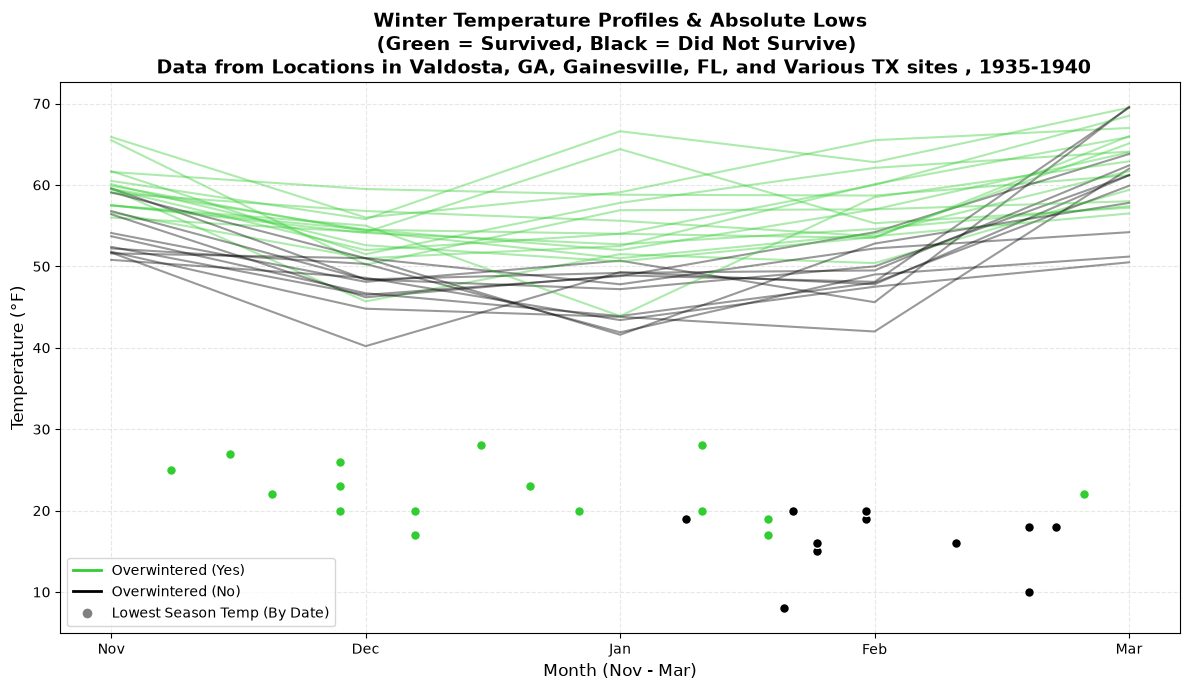

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Load the data 
csv_data = """Location,Year,Nov_Temp,Dec_Temp,Jan_Temp,Feb_Temp,Mar_Temp,Avg_Nov_Mar,Avg_Dec_Feb,Lowest_Temp,Lowest_Temp_Month,Lowest_Temp_Day,Overwintered
GAINESVILLE,1935-1936,65.5,50.2,56.9,57.0,64.0,58.7,54.7,23,Dec,21,Yes
GAINESVILLE,1936-1937,61.6,59.5,58.8,58.7,61.2,59.9,59.0,26,Nov,28,Yes
GAINESVILLE,1937-1938,60.5,55.8,66.6,62.8,69.5,61.0,58.4,20,Dec,7,Yes
VALDOSTA,1938-1939,65.9,56.0,59.1,65.5,67.0,62.7,60.2,20,Nov,28,Yes
VALDOSTA,1935-1936,59.5,45.7,51.5,50.4,59.4,49.2,58.8,20,Dec,27,Yes
VALDOSTA,1936-1937,56.0,54.2,64.4,55.3,57.2,57.6,58.0,23,Nov,28,Yes
VALDOSTA,1937-1938,56.6,51.0,52.5,60.1,65.9,57.2,54.5,17,Dec,7,Yes
DALLAS,1938-1939,61.7,51.5,57.8,62.1,64.1,59.3,57.0,22,Feb,24,Yes
DALLAS,1934-1935,59.6,48.4,49.2,49.5,62.4,49.0,53.8,8,Jan,21,No
DALLAS,1935-1936,51.8,44.8,43.8,42.0,62.0,49.0,48.5,10,Feb,18,No
DALLAS,1936-1937,52.2,50.3,41.9,49.0,51.2,48.9,47.1,19,Jan,9,No
DALLAS,1937-1938,52.4,46.5,48.8,54.2,63.8,49.8,53.1,19,Jan,31,No
MENARD,1938-1939,54.1,48.1,50.7,45.6,69.6,48.1,51.6,18,Feb,21,No
MENARD,1935-1936,53.7,46.7,43.9,48.0,59.9,46.2,50.4,18,Feb,18,No
MENARD,1936-1937,50.8,48.6,43.4,47.5,50.5,46.5,48.2,15,Jan,25,No
MENARD,1937-1938,56.4,46.2,48.9,48.1,69.5,47.7,52.6,20,Jan,31,No
SONORA,1938-1939,51.7,40.2,49.3,47.8,61.2,51.2,47.8,16,Feb,10,No
SONORA,1935-1936,56.8,48.4,47.2,50.0,61.2,52.7,48.5,18,Feb,18,No
SONORA,1936-1937,51.6,51.0,47.8,52.2,54.2,51.4,50.3,16,Jan,25,No
UVALDE,1935-1936,60.1,52.6,50.6,53.6,65.1,56.4,52.3,19,Jan,19,Yes
UVALDE,1936-1937,57.5,54.5,52.0,57.0,58.0,55.8,54.5,28,Dec,15,Yes
UVALDE,1937-1938,59.5,52.0,54.0,60.0,68.5,55.3,58.8,22,Nov,20,Yes
UVALDE,1938-1939,59.5,54.5,54.0,53.5,66.0,54.0,57.5,25,Nov,8,Yes
UVALDE,1939-1940,57.5,55.0,43.9,58.5,62.9,54.6,50.8,17,Jan,19,Yes
UVALDE,1940-1941,59.0,56.8,55.6,53.7,56.5,55.4,56.8,27,Nov,15,Yes
UVALDE,1941-1942,59.9,54.3,51.0,54.0,61.7,58.1,56.2,20,Jan,11,Yes
TEMPE,1936-1937,59.1,51.0,41.6,52.8,57.8,52.5,48.5,20,Jan,22,No
TEMPE,1937-1938,57.5,54.1,52.7,54.6,57.4,53.8,55.9,28,Jan,11,Yes"""

df = pd.read_csv(io.StringIO(csv_data))

# 2. X-axis Mapping
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
month_to_idx = {m: i for i, m in enumerate(months)}
days_in_month = {'Nov': 30, 'Dec': 31, 'Jan': 31, 'Feb': 28, 'Mar': 31}

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(12, 7))

# 4. Iterate over rows and plot
for _, row in df.iterrows():
    # Set color depending on if population overwintered successfully 
    color = 'limegreen' if row['Overwintered'] == 'Yes' else 'black'
    
    # Plot connecting line for the average monthly temperatures
    temps = [row['Nov_Temp'], row['Dec_Temp'], row['Jan_Temp'], row['Feb_Temp'], row['Mar_Temp']]
    ax.plot(months, temps, color=color, alpha=0.4, linewidth=1.5)
    
    # Calculate exactly where the 'lowest temperature' point should sit on the x-axis
    m_idx = month_to_idx[row['Lowest_Temp_Month']]
    day_fraction = (row['Lowest_Temp_Day'] - 1) / days_in_month[row['Lowest_Temp_Month']]
    x_pos = m_idx + day_fraction
    
    # Overlay the lowest temp point
    ax.scatter(x_pos, row['Lowest_Temp'], color=color, s=50, edgecolors='white', zorder=5)

# 5. Styling
ax.set_title('Winter Temperature Profiles & Absolute Lows\n(Green = Survived, Black = Did Not Survive) \n Data from Locations in Valdosta, GA, Gainesville, FL, and Various TX sites , 1935-1940', fontsize=14, fontweight='bold')
ax.set_ylabel('Temperature (°F)', fontsize=12)
ax.set_xlabel('Month (Nov - Mar)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='limegreen', lw=2, label='Overwintered (Yes)'),
    Line2D([0], [0], color='black', lw=2, label='Overwintered (No)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Lowest Season Temp (By Date)')
]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Inputting the complete dataset combining Rainfall, Mean Temp, and Lowest Temp from Table 1
data = {
    'Location': [
        'Gainesville', 'Gainesville', 'Gainesville', 'Gainesville',
        'Valdosta', 'Valdosta', 'Valdosta', 'Valdosta',
        'Dallas', 'Dallas', 'Dallas', 'Dallas', 'Dallas',
        'Menard', 'Menard', 'Menard', 'Menard',
        'Sonora', 'Sonora',
        'Uvalde', 'Uvalde', 'Uvalde', 'Uvalde', 'Uvalde', 'Uvalde', 'Uvalde',
        'Tempe', 'Tempe'
    ],
    'Year': [
        '1935-36', '1936-37', '1937-38', '1938-39',
        '1935-36', '1936-37', '1937-38', '1938-39',
        '1934-35', '1935-36', '1936-37', '1937-38', '1938-39',
        '1935-36', '1936-37', '1937-38', '1938-39',
        '1935-36', '1936-37',
        '1935-36', '1936-37', '1937-38', '1938-39', '1939-40', '1940-41', '1941-42',
        '1936-37', '1937-38'
    ],
    'Mean_Temp_Dec_Feb': [
        54.7, 59.0, 58.4, 60.2,
        49.2, 58.0, 54.5, 57.0,
        49.0, 43.5, 47.1, 49.8, 48.1,
        46.2, 46.5, 47.7, 51.2,
        48.5, 50.3,
        52.3, 54.5, 55.3, 54.0, 54.6, 55.4, 56.2,
        48.5, 55.9
    ],
    'Avg_Rain_Dec_Feb': [
        4.01, 2.74, 2.23, 1.96,
        2.99, 3.44, 1.20, 4.20,
        2.42, 0.55, 1.32, 5.09, 2.90,
        0.60, 0.40, 2.10, 1.50,
        0.00, 0.40,
        1.10, 0.80, 2.10, 0.60, 1.20, 2.90, 0.50,
        1.60, 0.70
    ],
    'Lowest_Temp': [
        23, 26, 20, 20,
        20, 23, 17, 22,
        8, 10, 19, 19, 18,
        18, 15, 20, 16,
        18, 16,
        19, 28, 22, 25, 17, 27, 20,
        20, 28
    ],
    'Overwintered': [
        'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'Yes', 'No', 'Yes', # 'Only in cage' implies field failure/mortality
        'No', 'No', 'No', 'No', 'No',
        'No', 'No', 'No', 'No',
        'No', 'No',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'No', 'Yes'
    ]
}

df = pd.DataFrame(data)

# 2. Define Mortality: 1 if failed to survive winter in nature, 0 if survived
df['Mortality'] = np.where(df['Overwintered'] == 'No', 1, 0)

# 3. Formulate the Logistic Regression Model
X = df[['Mean_Temp_Dec_Feb', 'Avg_Rain_Dec_Feb', 'Lowest_Temp']]
X = sm.add_constant(X)  # Adds intercept to the model
y = df['Mortality']

# 4. Fit the model
model = sm.Logit(y, X)
try:
    result = model.fit()
    print(result.summary())
except Exception as e:
    print(f"Convergence Note: {e}")
    # Because weather limits act as perfect thresholds (e.g., no survival below 49°F),
    # data exhibits near-perfect separation. Let's look at a Linear Probability Model as well.
    lpm = sm.OLS(y, X).fit()
    print("\n--- Linear Probability Model (OLS) to handle perfect threshold separation ---")
    print(lpm.summary())

         Current function value: inf
         Iterations: 35
Convergence Note: Singular matrix

--- Linear Probability Model (OLS) to handle perfect threshold separation ---
                            OLS Regression Results                            
Dep. Variable:              Mortality   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     18.58
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           1.90e-06
Time:                        13:31:43   Log-Likelihood:                -3.4431
No. Observations:                  28   AIC:                             14.89
Df Residuals:                      24   BIC:                             20.22
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std 

/home/tworm/Documents/SWIFT/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/tworm/Documents/SWIFT/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))



Processing Winter 2019-2020...
   Fetching Temperature (t2m)... Connecting to DestinE Zarr array for t2m (daily)...
Done.
    Fetching Precipitation (tp)... Connecting to DestinE Zarr array for tp (daily)...
Done.


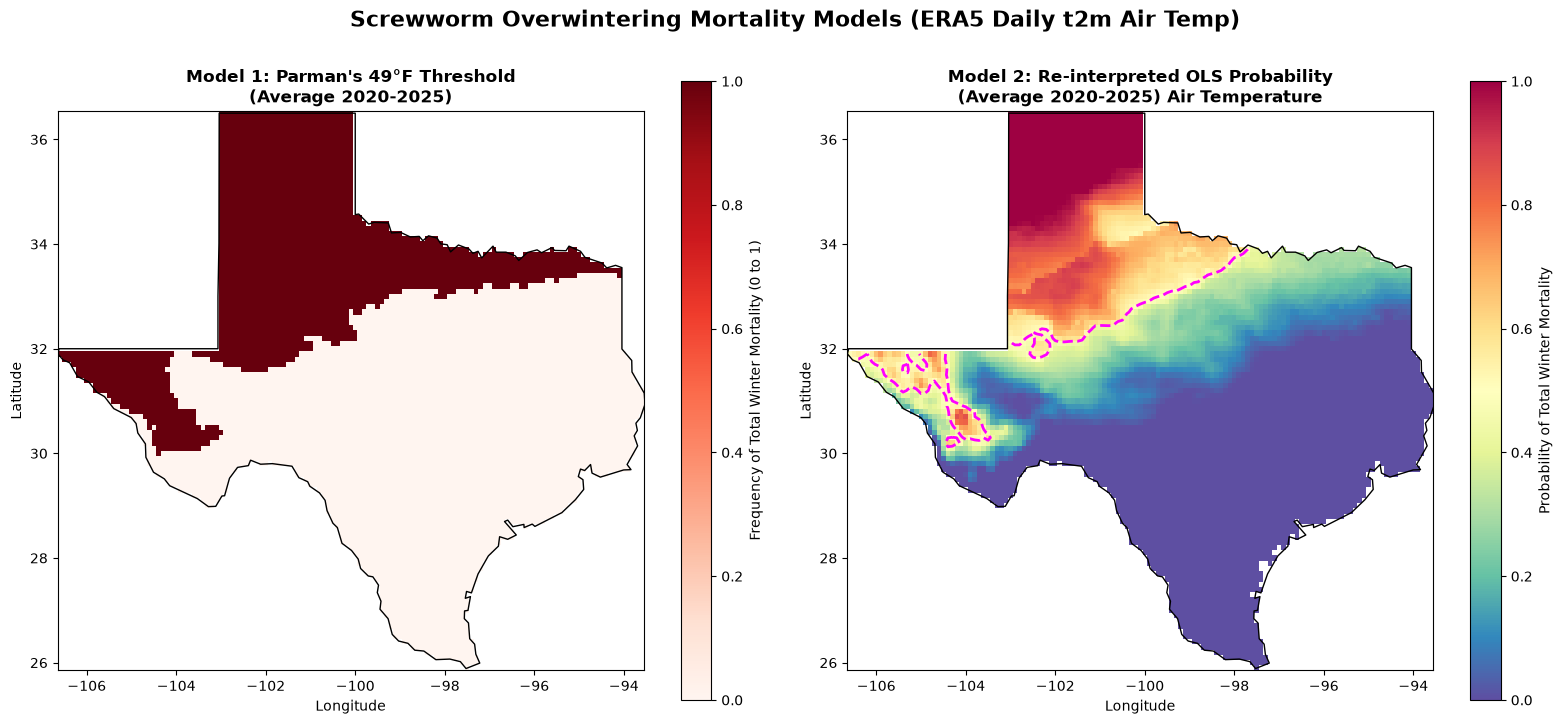

In [ ]:
# analyze_texas.py
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
from era5_downloader import fetch_era5_destine

def process_winter_models(years, bbox, region_gdf):
    """
    Downloads Dec-Feb data, calculates unit-corrected predictors, 
    applies both the Binary and OLS mortality models, and returns averaged results.
    """
    results_parman = []
    results_ols = []

    for year in years:
        print(f"\nProcessing Winter {year-1}-{year}...")
        # Winter season: Dec 1 of prev year to Feb 28 of current year
        winter_slice = slice(f"{year-1}-12-01", f"{year}-02-28")
        
        try:
            print("   Fetching Temperature (t2m)...", end=" ")
            t2m_k = fetch_era5_destine('t2m', timestep='daily', bbox=bbox, time_slice=winter_slice).compute()
            print("Done.")
            
            print("    Fetching Precipitation (tp)...", end=" ")
            # Note: ERA5 'tp' is total precipitation in meters
            tp_m = fetch_era5_destine('tp', timestep='daily', bbox=bbox, time_slice=winter_slice).compute()
            print("Done.")
            
        except Exception as e:
            print(f"   Failed to download {year}: {e}")
            continue

        # --- Unit Conversions for the Model ---
        # 1. Temperature: Kelvin to Fahrenheit
        t2m_f = ((t2m_k - 273.15) * 1.8) + 32
        
        # 2. Precipitation: Meters to Inches, then sum for winter, divide by 3 for monthly average
        tp_inches_daily = tp_m * 39.3701
        rain_avg_monthly = tp_inches_daily.sum(dim='valid_time') / 3.0

        # --- Calculate Independent Variables (X) ---
        t_mean = t2m_f.mean(dim='valid_time')
        t_min = t2m_f.min(dim='valid_time')

        # --- Apply Model 1: Parman's Absolute Threshold ---
        # 1 if Mean Temp < 49F (Mortality), 0 if >= 49F (Survival)`
        parman_mortality = xr.where(t_mean < 49.0, 1.0, 0.0)
        
        # --- Apply Model 2: Linear Probability Model (OLS) ---
        # P(Mortality) = 4.8219 - 0.0718(T_mean) + 0.0064(Rain_avg) - 0.0309(T_min)
        ols_prob = 4.8219 - (0.0718 * t_mean) + (0.0064 * rain_avg_monthly) - (0.0309 * t_min)
        # Cap probability bounds between 0 (0% chance of death) and 1 (100% chance of death)
        ols_prob = xr.where(ols_prob > 1.0, 1.0, ols_prob)
        ols_prob = xr.where(ols_prob < 0.0, 0.0, ols_prob)

        # Append to ensemble
        results_parman.append(parman_mortality)
        results_ols.append(ols_prob)

    # Calculate average across the 2020-2025 ensemble
    avg_parman = xr.concat(results_parman, dim='year').mean(dim='year')
    avg_ols = xr.concat(results_ols, dim='year').mean(dim='year')

    # Clip to Texas outline
    avg_parman = avg_parman.rio.write_crs("EPSG:4326").rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    avg_ols = avg_ols.rio.write_crs("EPSG:4326").rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    
    # DestinE coordinates are 0-360. We must momentarily shift the Texas boundary geometry to match.
    region_gdf_360 = region_gdf.copy()
    region_gdf_360.geometry = region_gdf.translate(xoff=360)

    parman_clipped = avg_parman.rio.clip(region_gdf_360.geometry.apply(mapping), region_gdf.crs, drop=True)
    ols_clipped = avg_ols.rio.clip(region_gdf_360.geometry.apply(mapping), region_gdf.crs, drop=True)

    # Shift coordinates back to -180/180 for standard map plotting
    parman_clipped = parman_clipped.assign_coords(longitude=parman_clipped.longitude - 360)
    ols_clipped = ols_clipped.assign_coords(longitude=ols_clipped.longitude - 360)

    return parman_clipped, ols_clipped

def plot_model_comparison(parman_map, ols_map, region_gdf):
    """Renders the side-by-side comparison of the two models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Model 1 Plot
    parman_map.plot(ax=axes[0], cmap='Reds', vmin=0, vmax=1, 
                    cbar_kwargs={'label': 'Frequency of Total Winter Mortality (0 to 1)'})
    region_gdf.boundary.plot(ax=axes[0], color='black', linewidth=1)
    axes[0].set_title("Model 1: Parman's 49°F Threshold\n(Average 2020-2025)", fontweight='bold')
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

    # Model 2 Plot
    ols_map.plot(ax=axes[1], cmap='Spectral_r', vmin=0, vmax=1,
                 cbar_kwargs={'label': 'Probability of Total Winter Mortality'})
    region_gdf.boundary.plot(ax=axes[1], color='black', linewidth=1)
    # Add a contour showing the 50% probability line
    ols_map.plot.contour(ax=axes[1], levels=[0.5], colors=['magenta'], linewidths=[2], linestyles=['--'])
    axes[1].set_title("Model 2: Re-interpreted OLS Probability\n(Average 2020-2025) Air Temperature", fontweight='bold')
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

    plt.suptitle("Screwworm Overwintering Mortality Models (ERA5 Daily t2m Air Temp)", fontsize=16, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Define Texas using DestinE compatible longitudes (0-360)
    # Texas is roughly Lat: 37 to 25. Lon: -107 to -93 -> (253 to 267)
    texas_bbox = {'latitude': slice(37, 25), 'longitude': slice(253, 267)}
    
    # 2. Fetch standard Texas outline
    us_states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
    texas_geom = us_states[us_states['name'] == 'Texas'].to_crs(epsg=4326)

    # 3. Run Analysis for 2020 through 2025
    parman_res, ols_res = process_winter_models(years=range(2020, 2021), bbox=texas_bbox, region_gdf=texas_geom)

    # 4. Visualize
    plot_model_comparison(parman_res, ols_res, texas_geom)


In [5]:
results_parman

NameError: name 'results_parman' is not defined

This gives $$\text{Probability of Mortality} = 4.8219 - 0.0718(\text{Mean Temp}) + 0.0064(\text{Avg Rain}) - 0.0309(\text{Lowest Temp})$$